In [5]:
%config InlineBackend.figure_format = 'svg'

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import pathlib
from torch.utils.data import TensorDataset, DataLoader, random_split
from tqdm.notebook import tqdm

_nb_file = globals().get('__vsc_ipynb_file__', '')
if _nb_file:
    os.chdir(pathlib.Path(_nb_file).resolve().parent)

project_root = str(pathlib.Path(os.getcwd()).parent)
sys.path.insert(0, project_root)

from src.mgf_dataset import simulate_ou_process
from src.model import SimpleTransformer
from src.utils import load_full_config

cfg = load_full_config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [6]:
# --- Sweep config ---
TRAIN_THETAS    = np.linspace(0.1, 4.0, 12)   # theta values to train on
TEST_THETAS     = np.linspace(0.1, 4.0, 30)   # theta values to test on

# --- Data config ---
SEQ_LEN         = 100
NUM_TRAIN_TRAJ  = 1000
NUM_TEST_TRAJ   = 2000
MU              = cfg['physics']['mu']
DT              = cfg['physics']['dt']
MARGINAL_VAR    = cfg['physics']['marginal_variance']

# --- Training config ---
EPOCHS          = 150
BATCH_SIZE      = cfg['hyperparameters']['batch_size']
LR              = cfg['hyperparameters']['learning_rate']
ARCH            = cfg['architecture']

In [7]:
def make_data(theta_val, num_traj, seq_len):
    """Generate trajectories and conditional mean targets for a single theta."""
    theta_val = float(theta_val)
    theta_t = torch.full((num_traj,), theta_val)
    D_t     = MARGINAL_VAR * theta_t
    trajs   = simulate_ou_process(num_traj, seq_len, theta_t, MU, D_t, DT)
    targets = torch.zeros(num_traj, seq_len, ARCH['d_output'])
    exp_dt  = np.exp(-theta_val * DT)
    targets[:, :, 0] = MU + (trajs[:, :, 0] - MU) * exp_dt
    cond_var = MARGINAL_VAR * (1 - np.exp(-2 * theta_val * DT))
    targets[:, :, 1] = cond_var
    return trajs, targets


def train_model(theta_val):
    """Train a fresh model on single-theta data, return trained model."""
    trajs, targets = make_data(theta_val, NUM_TRAIN_TRAJ, SEQ_LEN)

    dataset = TensorDataset(trajs, targets)
    train_size = int(0.8 * len(dataset))
    val_size   = len(dataset) - train_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    model = SimpleTransformer(**ARCH).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    model.train()
    for _ in range(EPOCHS):
        for X, Y in train_loader:
            X, Y = X.to(device), Y.to(device)
            preds, _ = model(X)
            loss = criterion(preds, Y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    model.eval()
    return model


def eval_mse(model, theta_val):
    """Evaluate MSE of conditional mean prediction for a given test theta."""
    trajs, targets = make_data(theta_val, NUM_TEST_TRAJ, SEQ_LEN)
    trajs, targets = trajs.to(device), targets.to(device)
    with torch.no_grad():
        preds, _ = model(trajs)
    mse = nn.functional.mse_loss(preds[:, -1, 0], targets[:, -1, 0]).item()
    return mse

In [8]:
mse_grid = np.zeros((len(TRAIN_THETAS), len(TEST_THETAS)))

for i, train_theta in enumerate(tqdm(TRAIN_THETAS, desc='Training theta')):
    model = train_model(train_theta)
    for j, test_theta in enumerate(TEST_THETAS):
        mse_grid[i, j] = eval_mse(model, test_theta)

print('Sweep complete.')

Training theta:   0%|          | 0/12 [00:00<?, ?it/s]

Sweep complete.


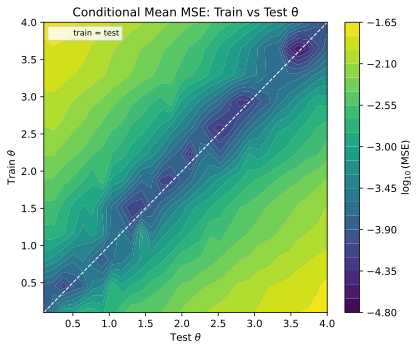

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))

cf = ax.contourf(
    TEST_THETAS, TRAIN_THETAS, np.log10(mse_grid + 1e-12),
    levels=20, cmap='viridis'
)
ax.contour(
    TEST_THETAS, TRAIN_THETAS, np.log10(mse_grid + 1e-12),
    levels=20, colors='k', linewidths=0.3, alpha=0.4
)
plt.colorbar(cf, ax=ax, label=r'$\log_{10}$(MSE)')

# diagonal: train theta == test theta
diag = np.linspace(max(TRAIN_THETAS.min(), TEST_THETAS.min()),
                   min(TRAIN_THETAS.max(), TEST_THETAS.max()), 100)
ax.plot(diag, diag, 'w--', linewidth=1, label='train = test')
ax.legend(loc='upper left', fontsize=8)

ax.set_xlabel(r'Test $\theta$')
ax.set_ylabel(r'Train $\theta$')
ax.set_title('Conditional Mean MSE: Train vs Test θ')

plt.tight_layout()
plt.show()